In [1]:
import numpy as numpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr


In [2]:
health_data = pd.read_csv("health data.csv", sep=";")
health_data
econ_data = pd.read_csv("econ data2.csv", sep=";")
econ_data

,Country Name,Country Code,Time,Time Code,GDP per capita (current US$) [NY.GDP.PCAP.CD],Gini index [SI.POV.GINI],Human capital index (HCI) (scale 0-1) [HD.HCI.OVRL],Consumer price index (2010 = 100) [FP.CPI.TOTL],"Inflation, consumer prices (annual %) [FP.CPI.TOTL.ZG]","Unemployment, total (% of total labor force) (national estimate) [SL.UEM.TOTL.NE.ZS]",UHC service coverage index [SH.UHC.SRVS.CV.XD],Real interest rate (%) [FR.INR.RINR],"Current account balance (BoP, current US$) [BN.CAB.XOKA.CD]"
0,Afghanistan,AFG,2022.0,YR2022,357.261152798144,..,..,189.23795275112,13.7121023720065,..,..,..,..
1,Albania,ALB,2022.0,YR2022,6846.42669381643,..,..,131.750834819418,6.72520271530048,10.785,..,-3.05376660800019,-1116775476.01529
2,Algeria,DZA,2022.0,YR2022,4961.55257664733,..,..,181.619931977783,9.26551551551553,..,..,-12.1603164443163,19433089540.8216
3,American Samoa,ASM,2022.0,YR2022,18017.4589383973,..,..,..,..,..,..,..,..
4,Andorra,AND,2022.0,YR2022,42414.0590092117,..,..,..,..,..,..,..,393619769.911968
...,...,...,...,...,...,...,...,...,...,...,...,...,...
266,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
267,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
268,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
269,Data from database: World Development Indicators,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
dataset = pd.merge(health_data, econ_data, how = 'inner', on = 'Country Code')
dataset

,Country Name_x,Country Code,Year,Year Code,Current health expenditure (% of GDP) [SH.XPD.CHEX.GD.ZS],Current health expenditure per capita (current US$) [SH.XPD.CHEX.PC.CD],Domestic general government health expenditure (% of current health expenditure) [SH.XPD.GHED.CH.ZS],Domestic general government health expenditure (% of GDP) [SH.XPD.GHED.GD.ZS],Domestic general government health expenditure per capita (current US$) [SH.XPD.GHED.PC.CD],Domestic private health expenditure per capita (current US$) [SH.XPD.PVTD.PC.CD],...,Time Code,GDP per capita (current US$) [NY.GDP.PCAP.CD],Gini index [SI.POV.GINI],Human capital index (HCI) (scale 0-1) [HD.HCI.OVRL],Consumer price index (2010 = 100) [FP.CPI.TOTL],"Inflation, consumer prices (annual %) [FP.CPI.TOTL.ZG]","Unemployment, total (% of total labor force) (national estimate) [SL.UEM.TOTL.NE.ZS]",UHC service coverage index [SH.UHC.SRVS.CV.XD],Real interest rate (%) [FR.INR.RINR],"Current account balance (BoP, current US$) [BN.CAB.XOKA.CD]"
0,Afghanistan,AFG,2020.0,YR2020,15.53361416,80.0892334,7.63642311,1.18621242,6.11595245,61.05325142,...,YR2022,357.261152798144,..,..,189.23795275112,13.7121023720065,..,..,..,..
1,Albania,ALB,2020.0,YR2020,7.50389433,396.17477417,39.84601212,2.99000263,157.8598434,235.63640505,...,YR2022,6846.42669381643,..,..,131.750834819418,6.72520271530048,10.785,..,-3.05376660800019,-1116775476.01529
2,Algeria,DZA,2020.0,YR2020,5.63831711,211.07276917,58.73843765,3.31185937,123.98084324,87.00733874,...,YR2022,4961.55257664733,..,..,181.619931977783,9.26551551551553,..,..,-12.1603164443163,19433089540.8216
3,American Samoa,ASM,2020.0,YR2020,..,..,..,..,..,..,...,YR2022,18017.4589383973,..,..,..,..,..,..,..,..
4,Andorra,AND,2020.0,YR2020,8.78673935,3282.81738281,72.60459137,6.37670708,2382.4043855,900.4129451,...,YR2022,42414.0590092117,..,..,..,..,..,..,..,393619769.911968
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237,Last Updated: 07/02/2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
238,Last Updated: 07/02/2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
239,Last Updated: 07/02/2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
240,Last Updated: 07/02/2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
dataset_cleaned = dataset.copy()
dataset_cleaned = dataset_cleaned.drop(columns=['Country Code', 'Year', 'Year Code', 'Country Name_y', 'Time', 'Time Code', 'Gini index [SI.POV.GINI]', 'Human capital index (HCI) (scale 0-1) [HD.HCI.OVRL]', 'UHC service coverage index [SH.UHC.SRVS.CV.XD]', 'Consumer price index (2010 = 100) [FP.CPI.TOTL]', 'Inflation, consumer prices (annual %) [FP.CPI.TOTL.ZG]', "Unemployment, total (% of total labor force) (national estimate) [SL.UEM.TOTL.NE.ZS]", 'Real interest rate (%) [FR.INR.RINR]','Current account balance (BoP, current US$) [BN.CAB.XOKA.CD]'])
dataset_cleaned = dataset_cleaned.dropna()
dataset_cleaned

,Country Name_x,Current health expenditure (% of GDP) [SH.XPD.CHEX.GD.ZS],Current health expenditure per capita (current US$) [SH.XPD.CHEX.PC.CD],Domestic general government health expenditure (% of current health expenditure) [SH.XPD.GHED.CH.ZS],Domestic general government health expenditure (% of GDP) [SH.XPD.GHED.GD.ZS],Domestic general government health expenditure per capita (current US$) [SH.XPD.GHED.PC.CD],Domestic private health expenditure per capita (current US$) [SH.XPD.PVTD.PC.CD],Domestic private health expenditure (% of current health expenditure) [SH.XPD.PVTD.CH.ZS],External health expenditure per capita (current US$) [SH.XPD.EHEX.PC.CD],Out-of-pocket expenditure (% of current health expenditure) [SH.XPD.OOPC.CH.ZS],Out-of-pocket expenditure per capita (current US$) [SH.XPD.OOPC.PC.CD],"Physicians (per 1,000 people) [SH.MED.PHYS.ZS]","Hospital beds (per 1,000 people) [SH.MED.BEDS.ZS]","Nurses and midwives (per 1,000 people) [SH.MED.NUMW.P3]","Life expectancy at birth, total (years) [SP.DYN.LE00.IN]","Mortality rate, infant (per 1,000 live births) [SP.DYN.IMRT.IN]","Maternal mortality ratio (modeled estimate, per 100,000 live births) [SH.STA.MMRT]","Mortality rate, under-5 (per 1,000) [SH.DYN.MORT]",GDP per capita (current US$) [NY.GDP.PCAP.CD]
0,Afghanistan,15.53361416,80.0892334,7.63642311,1.18621242,6.11595245,61.05325142,76.23153687,12.9200274,74.81396484,59.91792599,0.254,0.34,..,61.454000,55.3,634,61.3,357.261152798144
1,Albania,7.50389433,396.17477417,39.84601212,2.99000263,157.8598434,235.63640505,59.47789001,2.67851936,59.39613342,235.31249191,1.883,2.91,5.831,77.824000,8.1,7,9.4,6846.42669381643
2,Algeria,5.63831711,211.07276917,58.73843765,3.31185937,123.98084324,87.00733874,41.22148895,0.08457764,39.64334869,83.67631674,..,..,..,73.257000,20.4,97,22.9,4961.55257664733
3,American Samoa,..,..,..,..,..,..,..,..,..,..,..,..,..,72.672000,..,..,..,18017.4589383973
4,Andorra,8.78673935,3282.81738281,72.60459137,6.37670708,2382.4043855,900.4129451,27.44039154,..,11.15107918,366.06957101,..,..,..,79.418000,2.7,48,2.9,42414.0590092117
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,Virgin Islands (U.S.),..,..,..,..,..,..,..,..,..,..,..,..,..,79.819512,..,..,..,44320.909185774
213,West Bank and Gaza,10.27610207,314.82254028,37.50418472,3.85396838,118.07163039,157.7140115,50.09616089,39.03690796,38.39196014,120.86655363,..,..,..,74.998000,13.2,20,15.2,3799.95527015163
214,"Yemen, Rep.",5.77270842,32.30203629,6.73523283,0.38880539,2.17561756,22.88564683,70.84892273,7.24077373,69.91931152,22.58536249,..,..,..,66.435000,37.4,135,43.2,615.702077657755
215,Zambia,6.3067441,60.01779938,56.98109055,3.59365153,34.19879606,6.01106737,10.01547432,19.80793504,8.11366367,4.86964251,0.255,..,1.637,63.361000,34.5,99,52.4,1447.12310138035


In [5]:
import numpy as np
dataset_cleaned = dataset_cleaned.replace("..", np.nan)

for col in dataset_cleaned.columns[1:]:
    dataset_cleaned[col] = pd.to_numeric(dataset_cleaned[col], errors='coerce')

In [6]:

dataset_cleaned = dataset_cleaned.dropna(how='any')

dataset_cleaned

,Country Name_x,Current health expenditure (% of GDP) [SH.XPD.CHEX.GD.ZS],Current health expenditure per capita (current US$) [SH.XPD.CHEX.PC.CD],Domestic general government health expenditure (% of current health expenditure) [SH.XPD.GHED.CH.ZS],Domestic general government health expenditure (% of GDP) [SH.XPD.GHED.GD.ZS],Domestic general government health expenditure per capita (current US$) [SH.XPD.GHED.PC.CD],Domestic private health expenditure per capita (current US$) [SH.XPD.PVTD.PC.CD],Domestic private health expenditure (% of current health expenditure) [SH.XPD.PVTD.CH.ZS],External health expenditure per capita (current US$) [SH.XPD.EHEX.PC.CD],Out-of-pocket expenditure (% of current health expenditure) [SH.XPD.OOPC.CH.ZS],Out-of-pocket expenditure per capita (current US$) [SH.XPD.OOPC.PC.CD],"Physicians (per 1,000 people) [SH.MED.PHYS.ZS]","Hospital beds (per 1,000 people) [SH.MED.BEDS.ZS]","Nurses and midwives (per 1,000 people) [SH.MED.NUMW.P3]","Life expectancy at birth, total (years) [SP.DYN.LE00.IN]","Mortality rate, infant (per 1,000 live births) [SP.DYN.IMRT.IN]","Maternal mortality ratio (modeled estimate, per 100,000 live births) [SH.STA.MMRT]","Mortality rate, under-5 (per 1,000) [SH.DYN.MORT]",GDP per capita (current US$) [NY.GDP.PCAP.CD]
1,Albania,7.503894,396.174774,39.846012,2.990003,157.859843,235.636405,59.477890,2.678519,59.396133,235.312492,1.883,2.91,5.831,77.824000,8.1,7.0,9.4,6846.426694
7,Argentina,10.450306,891.996216,63.984512,6.686577,570.739439,318.766353,35.736290,2.490456,21.756790,194.069757,3.895,3.20,5.447,75.878000,8.7,40.0,10.3,13935.681111
11,Austria,11.316411,5531.023438,76.851120,8.696789,4250.653240,1280.369870,23.148878,0.000000,16.471933,911.066505,5.324,7.06,10.770,81.192683,2.9,6.0,3.4,52176.664914
18,Belgium,11.264819,5144.981445,78.123894,8.800515,4019.459717,1125.521794,21.876110,0.000000,17.189375,884.390194,3.208,5.52,20.130,80.695122,3.2,4.0,3.9,50822.251854
22,Bhutan,4.084515,134.137238,78.007736,3.186238,104.637415,22.609816,16.855736,6.890002,15.424659,20.690210,0.484,2.12,2.075,72.253000,20.3,51.0,25.5,3711.327680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199,Turkmenistan,5.572261,420.008331,18.370010,1.023625,77.155574,342.101181,81.451050,0.751567,76.360359,320.719855,2.179,4.09,3.991,68.846000,33.2,5.0,42.6,8156.352120
204,United Arab Emirates,5.824770,2154.411133,60.986095,3.552300,1313.891265,840.519870,39.013901,0.000000,11.210545,241.521229,2.879,1.94,6.357,81.936000,4.7,6.0,6.0,49899.065298
205,United Kingdom,11.965477,4816.152832,85.025360,10.173690,4094.951548,720.745611,14.965173,0.455742,11.450068,551.452821,3.041,2.43,8.962,80.331756,3.9,14.0,4.4,46062.991408
206,United States,18.813253,11672.770508,57.041756,10.731410,6658.352881,5014.417166,42.958244,0.000000,10.052074,1173.355498,3.555,2.74,12.470,76.980488,5.5,22.0,6.5,77860.911291


In [7]:
dataset_cleaned.rename(columns={
    'Country Name_x': 'Country Name',
    'Current health expenditure (% of GDP) [SH.XPD.CHEX.GD.ZS]': 'HealthExp(% of GDP)',
    'Current health expenditure per capita (current US$) [SH.XPD.CHEX.PC.CD]': 'HealthExp(current US$)',
    'Domestic general government health expenditure (% of current health expenditure) [SH.XPD.GHED.CH.ZS]': 'DomesticExp(% of HE)',
    'Domestic general government health expenditure (% of GDP) [SH.XPD.GHED.GD.ZS]': 'DomesticExp(% of GDP)',
    'Domestic general government health expenditure per capita (current US$) [SH.XPD.GHED.PC.CD]': 'DomesticExp(current US$)',
    'Domestic private health expenditure per capita (current US$) [SH.XPD.PVTD.PC.CD]': 'PrivExp(current US$)',
    'Domestic private health expenditure (% of current health expenditure) [SH.XPD.PVTD.CH.ZS]': 'PrivExp(% of HE)',
    'External health expenditure per capita (current US$) [SH.XPD.EHEX.PC.CD]': 'ExternalExp(current US$)',
    'Out-of-pocket expenditure (% of current health expenditure) [SH.XPD.OOPC.CH.ZS]': 'Out-of-pocketExp(% of HE)',
    'Out-of-pocket expenditure per capita (current US$) [SH.XPD.OOPC.PC.CD]': 'Out-of-pocketExp(current US$)',
    'Physicians (per 1,000 people) [SH.MED.PHYS.ZS]': 'Physicians',
    'Hospital beds (per 1,000 people) [SH.MED.BEDS.ZS]': 'Hospital beds',
    'Nurses and midwives (per 1,000 people) [SH.MED.NUMW.P3]': 'Nurses and midwives',
    'Life expectancy at birth, total (years) [SP.DYN.LE00.IN]': 'Life expectancy at birth',
    'Mortality rate, infant (per 1,000 live births) [SP.DYN.IMRT.IN]': 'Mortality rate, infant',
    'Maternal mortality ratio (modeled estimate, per 100,000 live births) [SH.STA.MMRT]': 'Maternal mortality ratio',
    'Mortality rate, under-5 (per 1,000) [SH.DYN.MORT]': 'Mortality rate, under-5',
    'GDP per capita (current US$) [NY.GDP.PCAP.CD]': 'GDP per capita',

}, inplace=True)

In [8]:
dataset_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 61 entries, 1 to 208
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country Name                   61 non-null     object 
 1   HealthExp(% of GDP)            61 non-null     float64
 2   HealthExp(current US$)         61 non-null     float64
 3   DomesticExp(% of HE)           61 non-null     float64
 4   DomesticExp(% of GDP)          61 non-null     float64
 5   DomesticExp(current US$)       61 non-null     float64
 6   PrivExp(current US$)           61 non-null     float64
 7   PrivExp(% of HE)               61 non-null     float64
 8   ExternalExp(current US$)       61 non-null     float64
 9   Out-of-pocketExp(% of HE)      61 non-null     float64
 10  Out-of-pocketExp(current US$)  61 non-null     float64
 11  Physicians                     61 non-null     float64
 12  Hospital beds                  61 non-null     float64
 

/var/folders/bz/yzqc11sn1gj3p_f45_fhc_qc0000gn/T/ipykernel_15583/3777220626.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Life expectancy at birth", y="Country Name", data = top_20_life_expectancy, palette="viridis")


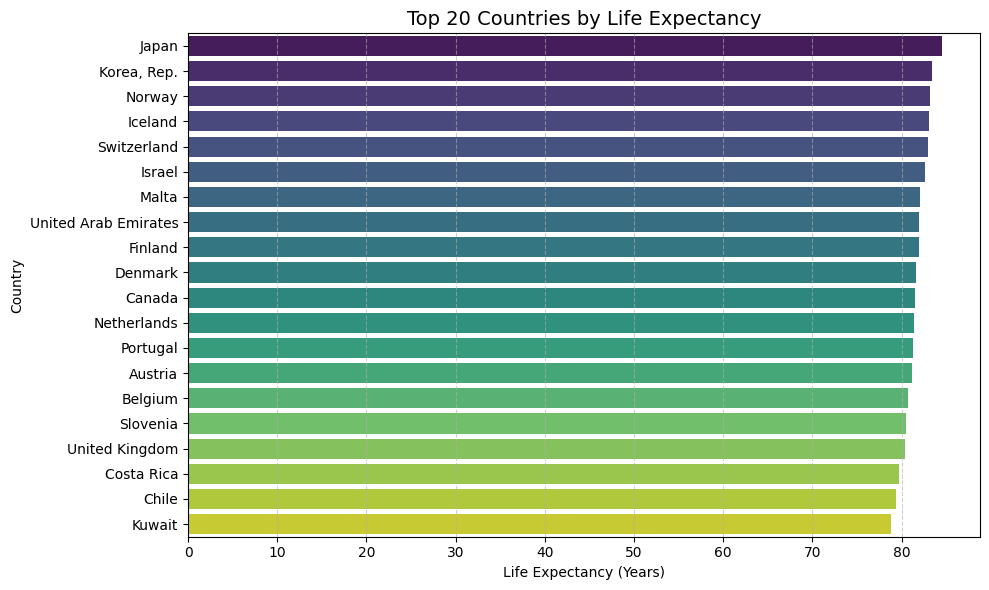

In [ ]:

top_20_life_expectancy = dataset_cleaned.nlargest(20, 'Life expectancy at birth')

plt.figure(figsize=(10, 6))
sns.barplot(x="Life expectancy at birth", y="Country Name", data = top_20_life_expectancy, palette="viridis")

plt.title("Top 20 Countries by Life Expectancy", fontsize=14)
plt.xlabel("Life Expectancy (Years)")
plt.ylabel("Country")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

/var/folders/bz/yzqc11sn1gj3p_f45_fhc_qc0000gn/T/ipykernel_15583/889951277.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="HealthExp(% of GDP)", y= "Country Name", data = top_20_health_expenditure, palette="viridis")


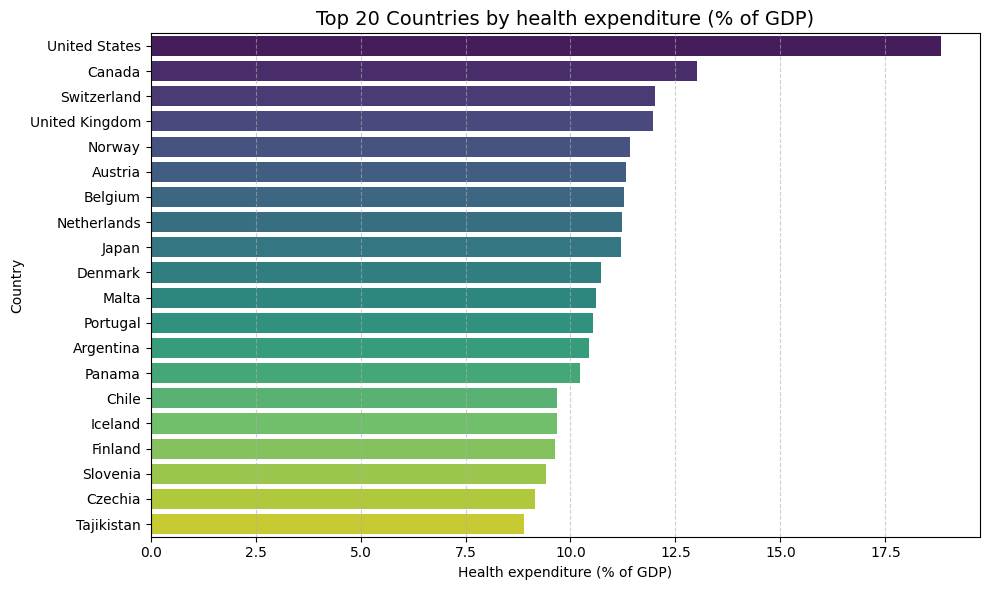

In [ ]:

top_20_health_expenditure = dataset_cleaned.nlargest(20, 'HealthExp(% of GDP)')

plt.figure(figsize=(10, 6))
sns.barplot(x="HealthExp(% of GDP)", y= "Country Name", data = top_20_health_expenditure, palette="viridis")

plt.title("Top 20 Countries by health expenditure (% of GDP)", fontsize=14)
plt.xlabel("Health expenditure (% of GDP)")
plt.ylabel("Country")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

/var/folders/bz/yzqc11sn1gj3p_f45_fhc_qc0000gn/T/ipykernel_15583/2262119767.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="HealthExp(current US$)", y= "Country Name", data = top_20_health_expenditure_per_capita, palette="viridis")


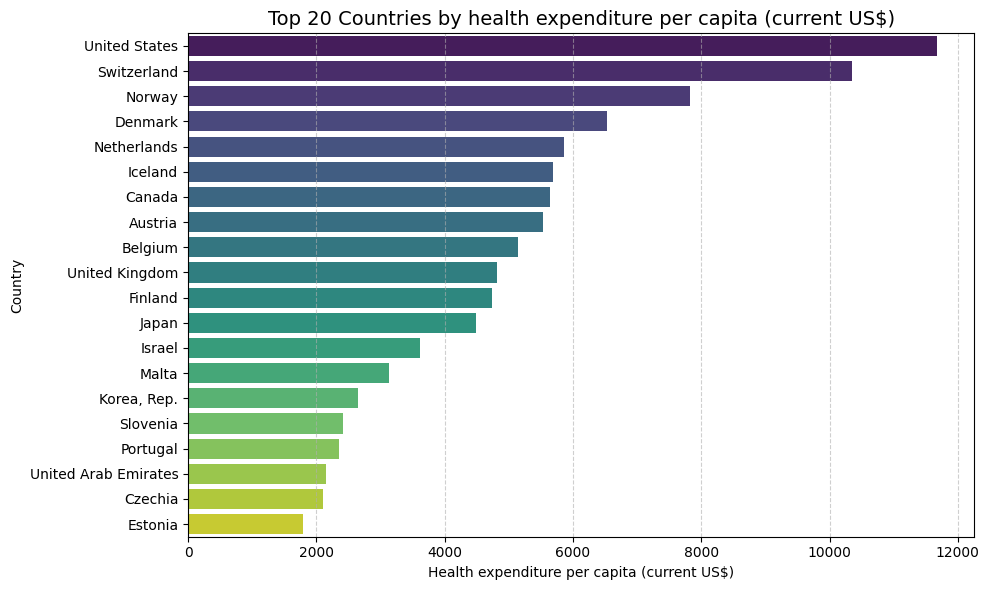

In [ ]:
top_20_health_expenditure_per_capita = dataset_cleaned.nlargest(20, 'HealthExp(current US$)')

plt.figure(figsize=(10, 6))
sns.barplot(x="HealthExp(current US$)", y= "Country Name", data = top_20_health_expenditure_per_capita, palette="viridis")

plt.title("Top 20 Countries by health expenditure per capita (current US$)", fontsize=14)
plt.xlabel("Health expenditure per capita (current US$)")
plt.ylabel("Country")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [12]:
copy_clean = dataset_cleaned.copy()

health_features  = copy_clean.iloc[:, 1:18]
numerical_features = copy_clean.iloc[:, 1:19]

dataset_healt_features = health_features
dataset_healt_features_values = health_features.values
numerical_features_values = numerical_features.values
dataset_healt_features_values

array([[7.50389433e+00, 3.96174774e+02, 3.98460121e+01, ...,
        8.10000000e+00, 7.00000000e+00, 9.40000000e+00],
       [1.04503059e+01, 8.91996216e+02, 6.39845123e+01, ...,
        8.70000000e+00, 4.00000000e+01, 1.03000000e+01],
       [1.13164110e+01, 5.53102344e+03, 7.68511200e+01, ...,
        2.90000000e+00, 6.00000000e+00, 3.40000000e+00],
       ...,
       [1.19654770e+01, 4.81615283e+03, 8.50253601e+01, ...,
        3.90000000e+00, 1.40000000e+01, 4.40000000e+00],
       [1.88132534e+01, 1.16727705e+04, 5.70417557e+01, ...,
        5.50000000e+00, 2.20000000e+01, 6.50000000e+00],
       [6.71439123e+00, 1.20290192e+02, 4.61574020e+01, ...,
        1.42000000e+01, 2.90000000e+01, 1.50000000e+01]])

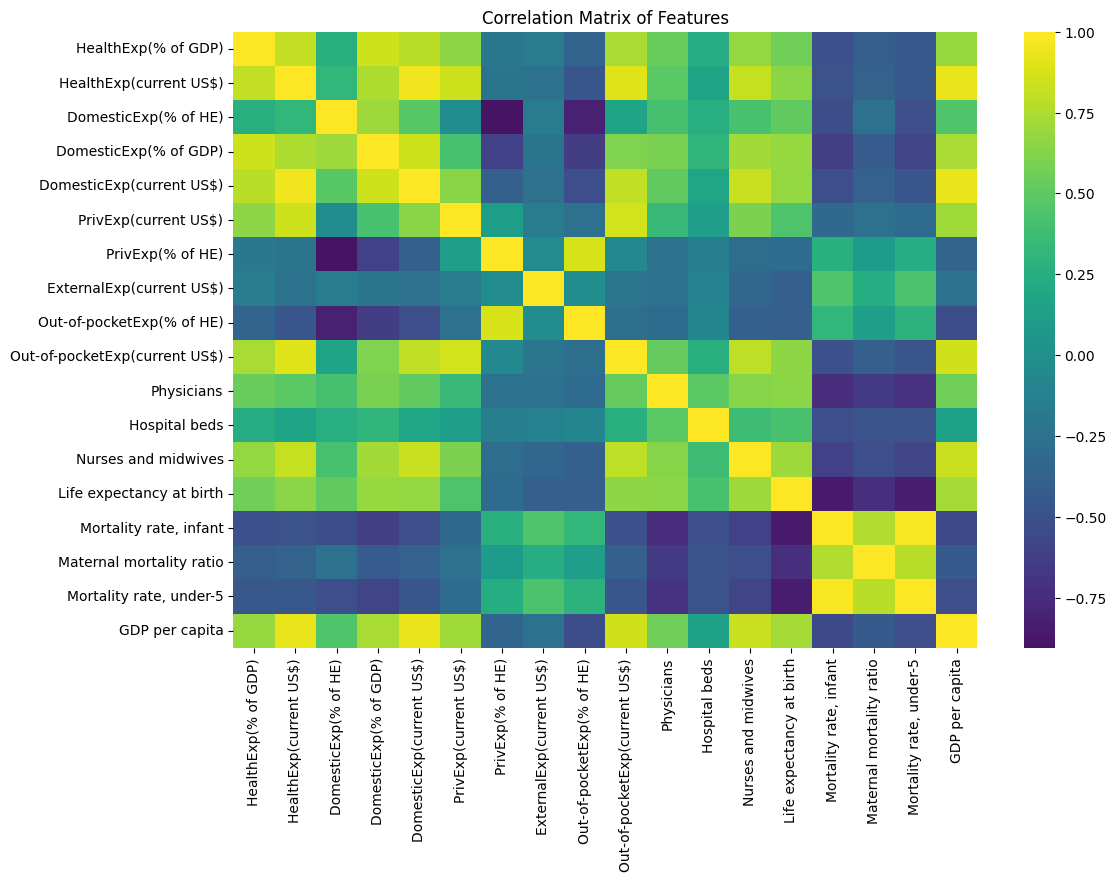

In [13]:

dataset_numerical_features_values_scaled = StandardScaler().fit_transform(numerical_features_values)
dataset_healt_features_values_scaled = StandardScaler().fit_transform(dataset_healt_features_values)

corr_matrix = pd.DataFrame(dataset_numerical_features_values_scaled, columns=numerical_features.columns).corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap="viridis", center=0, annot=False )
plt.title("Correlation Matrix of Features")
plt.show()

/var/folders/bz/yzqc11sn1gj3p_f45_fhc_qc0000gn/T/ipykernel_15583/1669720786.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), rotation=0, color='purple')
/var/folders/bz/yzqc11sn1gj3p_f45_fhc_qc0000gn/T/ipykernel_15583/1669720786.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), rotation=0, color='purple')
/var/folders/bz/yzqc11sn1gj3p_f45_fhc_qc0000gn/T/ipykernel_15583/1669720786.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), rotation=0, color='purple')
/var/folders/bz/yzqc11sn1gj3p_f45_fhc_qc0000gn/T/ipykernel_15583/1669720786.py:12: UserWarning: set_ticklabels() should only be used with a fixed number o

<Figure size 1200x800 with 0 Axes>

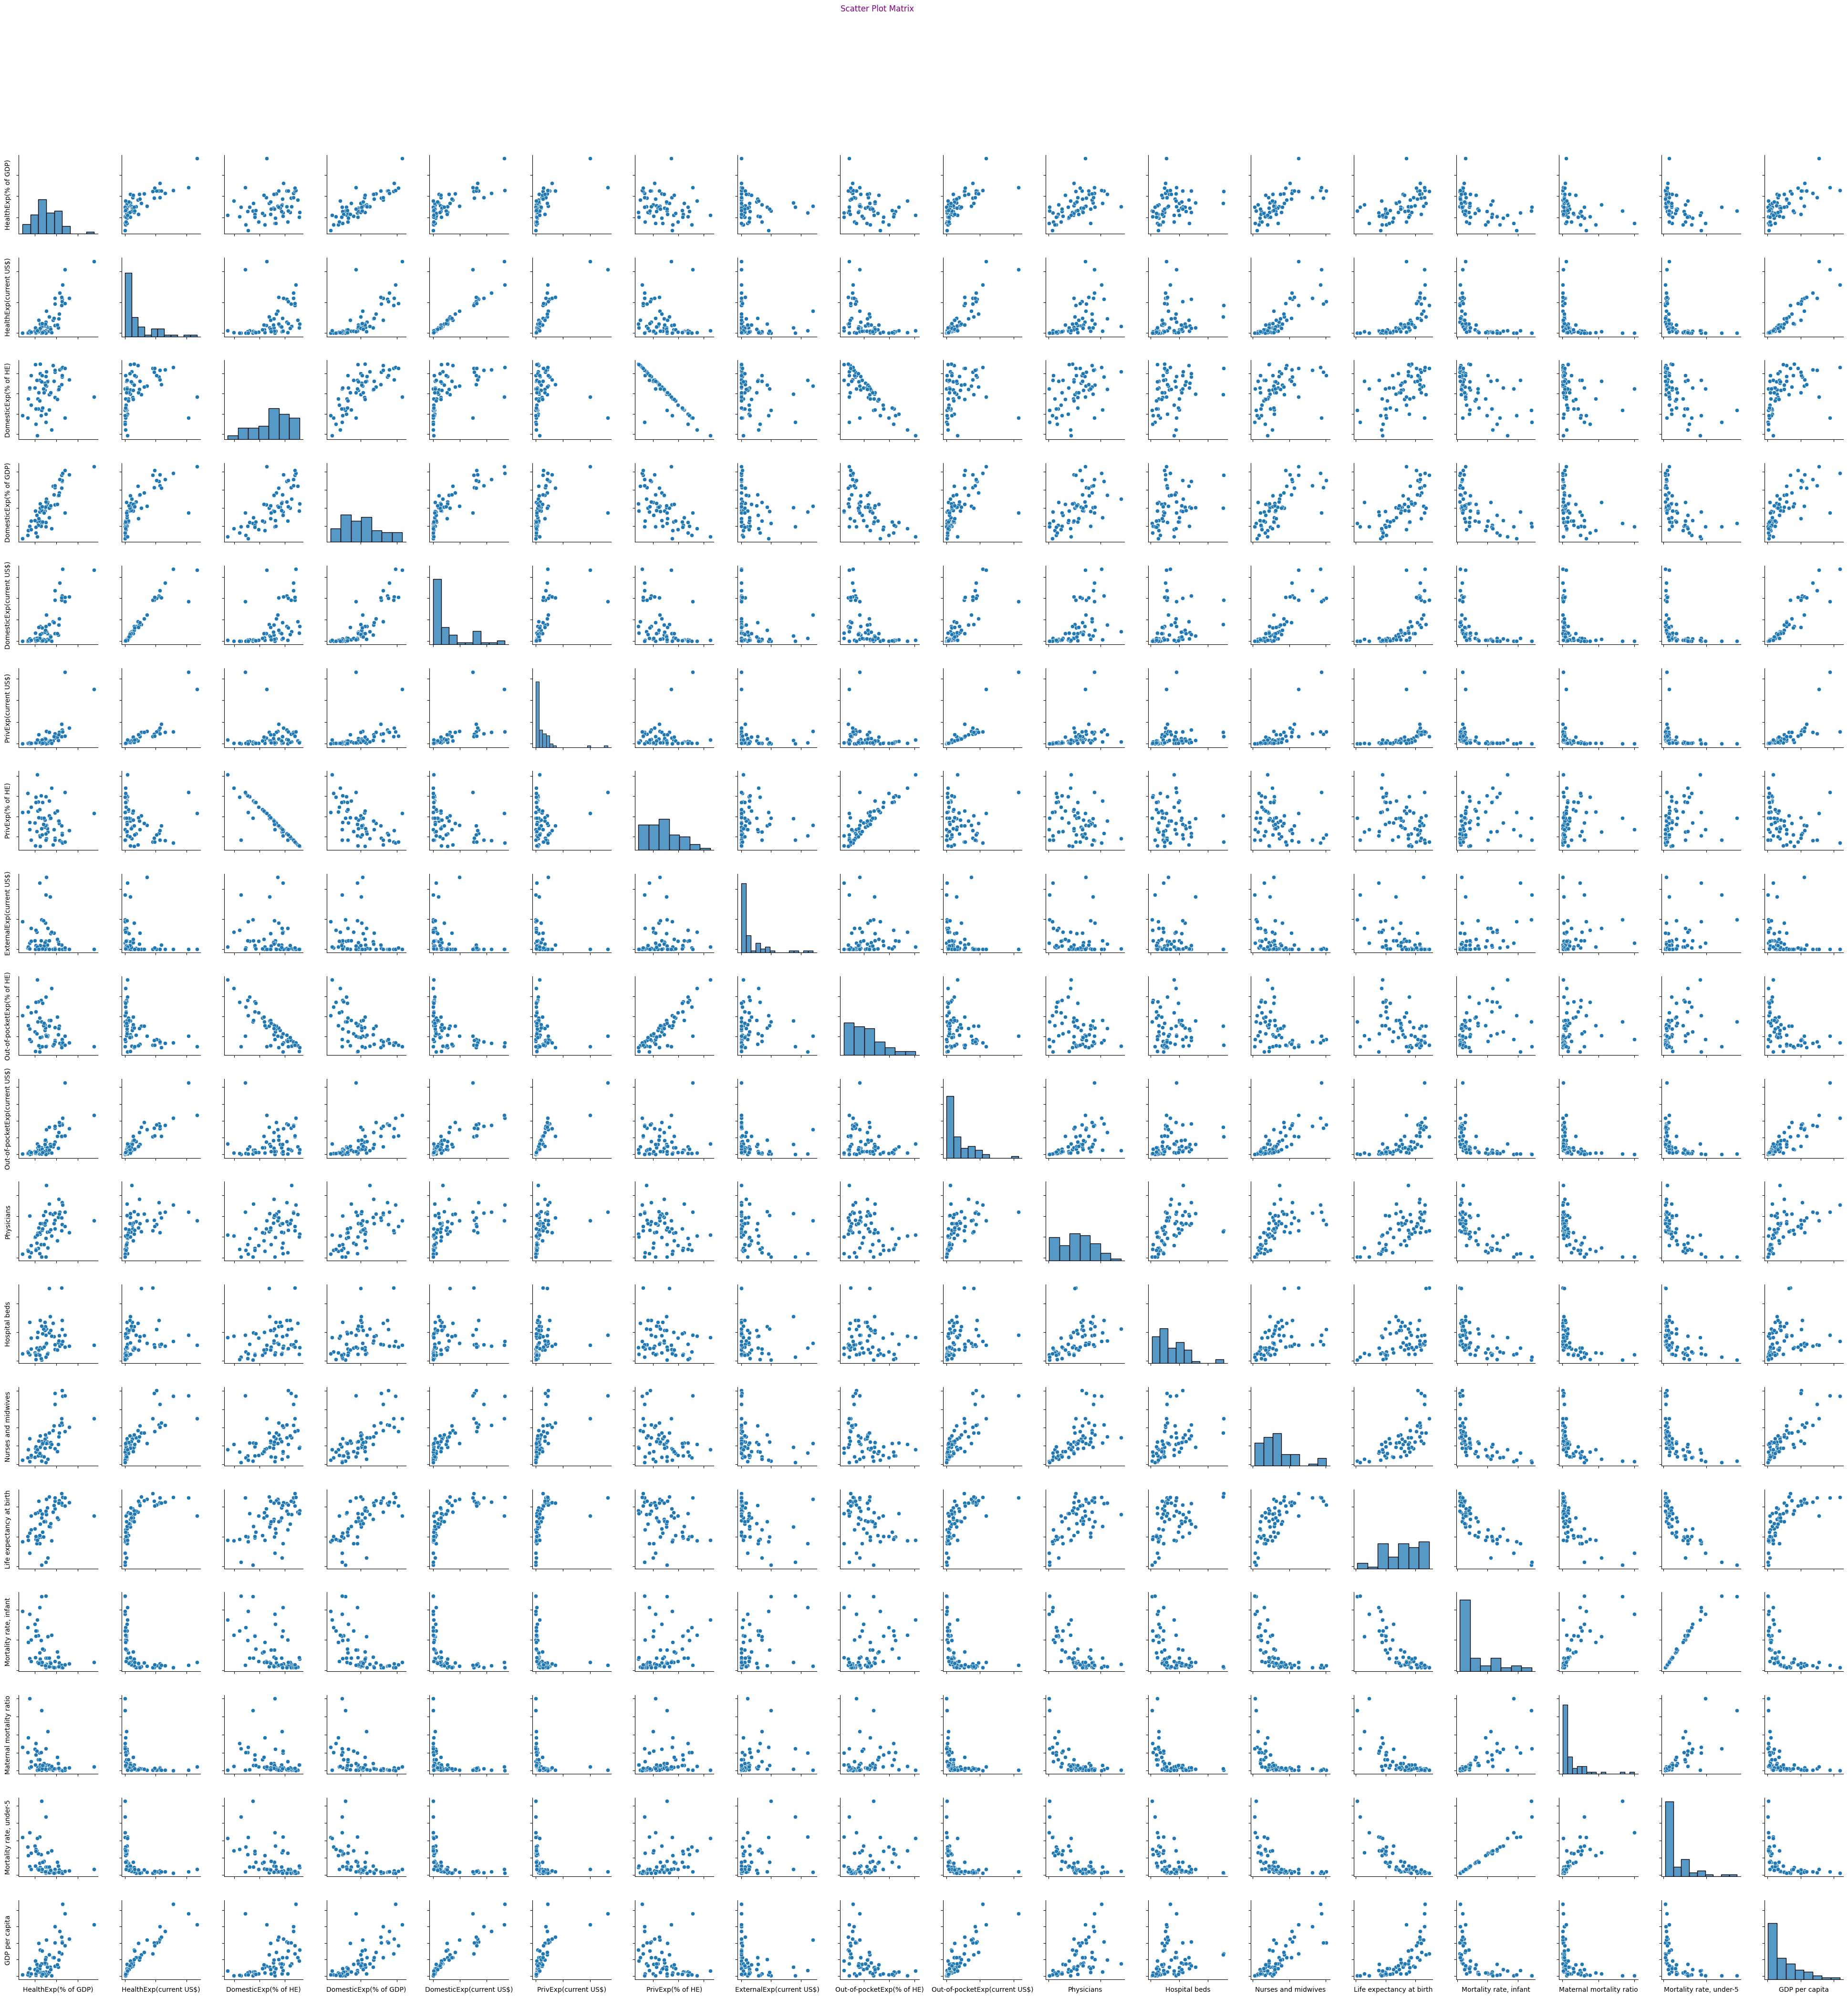

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

plt.figure(figsize=(12,8))
g = sns.pairplot(numerical_features)
for ax in g.axes.flatten():
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', color='purple')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, color='purple')
plt.suptitle("Scatter Plot Matrix", y=1.02, color='purple')
plt.subplots_adjust(top=0.95, bottom=0.1, left=0.1, right=0.95, hspace=0.3, wspace=0.3)

plt.show()

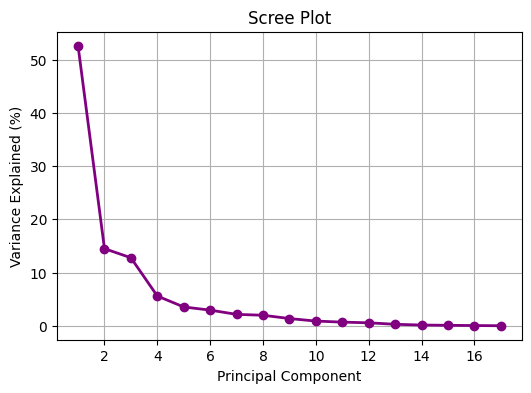

In [15]:
from sklearn.impute import SimpleImputer


pca = PCA()
X_pca = pca.fit_transform(dataset_healt_features_values_scaled)

for i in range(X_pca.shape[1]):
    copy_clean[f'PCA{i+1}'] = X_pca[:, i]

explained_var = pca.explained_variance_ratio_ * 100
plt.figure(figsize=(6,4))
plt.plot(range(1, len(explained_var)+1), explained_var, 'o-', linewidth=2, color='purple')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained (%)')
plt.grid(True)
plt.show()

In [16]:
gdp = copy_clean["GDP per capita"]


correlations = []
for i in range(X_pca.shape[1]):
    r, p = pearsonr(copy_clean[f'PCA{i+1}'], gdp)
    correlations.append((f'PCA{i+1}', r, p))


# Print correlation results
print("Correlation of PCs with GDP per capita:")
for pc, r, p in correlations:
    print(f"{pc}: r = {r:.3f}, p = {p:.4f}")

Correlation of PCs with GDP per capita:
PCA1: r = 0.864, p = 0.0000
PCA2: r = 0.116, p = 0.3728
PCA3: r = 0.320, p = 0.0120
PCA4: r = -0.062, p = 0.6347
PCA5: r = -0.095, p = 0.4682
PCA6: r = -0.128, p = 0.3238
PCA7: r = -0.058, p = 0.6593
PCA8: r = 0.180, p = 0.1644
PCA9: r = 0.022, p = 0.8688
PCA10: r = 0.061, p = 0.6392
PCA11: r = 0.123, p = 0.3435
PCA12: r = -0.031, p = 0.8114
PCA13: r = -0.033, p = 0.8012
PCA14: r = -0.000, p = 0.9997
PCA15: r = -0.066, p = 0.6150
PCA16: r = -0.070, p = 0.5912
PCA17: r = -0.014, p = 0.9135


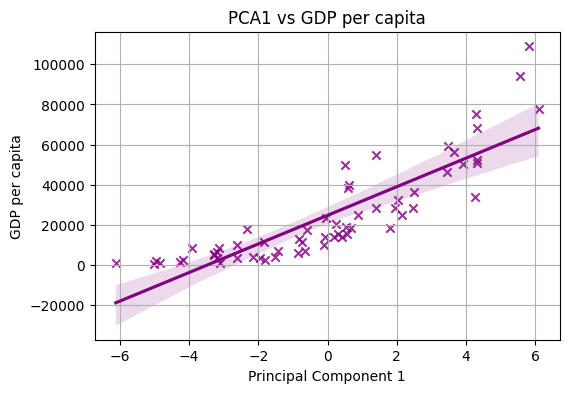

In [17]:

plt.figure(figsize=(6,4))
sns.regplot(x='PCA1', y='GDP per capita', data=copy_clean, ci=99, marker="x", color="purple", line_kws=dict(color="purple"))
plt.title('PCA1 vs GDP per capita')
plt.xlabel('Principal Component 1')
plt.ylabel('GDP per capita')
plt.grid(True)
plt.show()

In [18]:
loadings = pd.DataFrame(pca.components_.T, index=health_features.columns,
columns=[f'PC{i+1}' for i in range(len(health_features.columns))])
print("\nPCA Loadings (variable contributions):")
print(loadings)


PCA Loadings (variable contributions):
                                    PC1       PC2       PC3       PC4  \
HealthExp(% of GDP)            0.264114  0.142967  0.199471  0.123610   
HealthExp(current US$)         0.284100  0.170140  0.288899 -0.031408   
DomesticExp(% of HE)           0.202143 -0.485055 -0.006359 -0.112574   
DomesticExp(% of GDP)          0.294753 -0.152835  0.139254  0.003004   
DomesticExp(current US$)       0.290636  0.043581  0.254748 -0.071837   
PrivExp(current US$)           0.206815  0.340460  0.276334  0.038951   
PrivExp(% of HE)              -0.146843  0.545826 -0.138139 -0.027144   
ExternalExp(current US$)      -0.121996 -0.107769  0.204164  0.818348   
Out-of-pocketExp(% of HE)     -0.187490  0.415671 -0.244414 -0.013882   
Out-of-pocketExp(current US$)  0.266167  0.273440  0.192011  0.063293   
Physicians                     0.253171  0.015909 -0.215345  0.197756   
Hospital beds                  0.149428 -0.007176 -0.333599  0.443846   
Nurses and 

In [19]:
# Top 10 countries with highest PC1 scores
top_countries = copy_clean.sort_values("PCA1", ascending=False).head(10)
print("Top 10 countries by first principle component:")
print(top_countries[["Country Name", "PCA1"]])

# Bottom 10 countries with lowest PC1 scores
bottom_countries = copy_clean.sort_values("PCA1", ascending=True).head(10)
print("\nBottom 10 countries by first principle component:")
print(bottom_countries[["Country Name", "PCA1"]])

Top 10 countries by first principle component:
      Country Name      PCA1
206  United States  6.095149
147         Norway  5.805778
188    Switzerland  5.551450
18         Belgium  4.325213
11         Austria  4.316389
53         Denmark  4.304327
88         Iceland  4.279490
98           Japan  4.264885
67         Finland  3.901481
35          Canada  3.641163

Bottom 10 countries by first principle component:
     Country Name      PCA1
30   Burkina Faso -6.117541
134    Mozambique -5.006484
108       Lao PDR -4.958954
71    Gambia, The -4.838309
138         Nepal -4.258928
89          India -4.167912
199  Turkmenistan -3.911613
80      Guatemala -3.293099
90      Indonesia -3.285135
155   Philippines -3.198819


In [20]:

loadings = pd.DataFrame(
    pca.components_.T,       # transpose to get variables as rows
    index=health_features.columns,          # original variable names
    columns=[f'PCA{i+1}' for i in range(len(health_features.columns))]
)

# Display top 4 PCs
top4_loadings = loadings.iloc[:, :4]
print(top4_loadings)

                                   PCA1      PCA2      PCA3      PCA4
HealthExp(% of GDP)            0.264114  0.142967  0.199471  0.123610
HealthExp(current US$)         0.284100  0.170140  0.288899 -0.031408
DomesticExp(% of HE)           0.202143 -0.485055 -0.006359 -0.112574
DomesticExp(% of GDP)          0.294753 -0.152835  0.139254  0.003004
DomesticExp(current US$)       0.290636  0.043581  0.254748 -0.071837
PrivExp(current US$)           0.206815  0.340460  0.276334  0.038951
PrivExp(% of HE)              -0.146843  0.545826 -0.138139 -0.027144
ExternalExp(current US$)      -0.121996 -0.107769  0.204164  0.818348
Out-of-pocketExp(% of HE)     -0.187490  0.415671 -0.244414 -0.013882
Out-of-pocketExp(current US$)  0.266167  0.273440  0.192011  0.063293
Physicians                     0.253171  0.015909 -0.215345  0.197756
Hospital beds                  0.149428 -0.007176 -0.333599  0.443846
Nurses and midwives            0.290650  0.095802  0.074540 -0.015807
Life expectancy at b

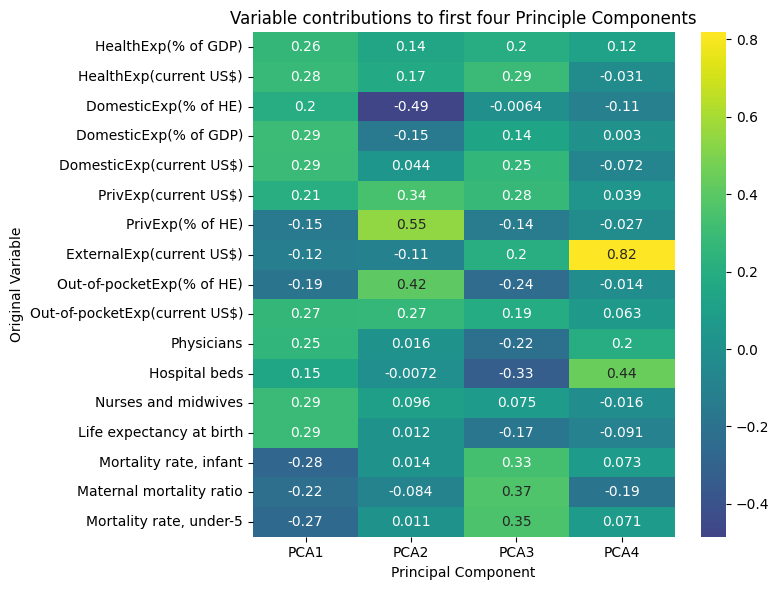

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(top4_loadings, annot=True, cmap="viridis", center=0)
plt.title("Variable contributions to first four Principle Components")
plt.xlabel("Principal Component")
plt.ylabel("Original Variable")
plt.tight_layout()
plt.show()


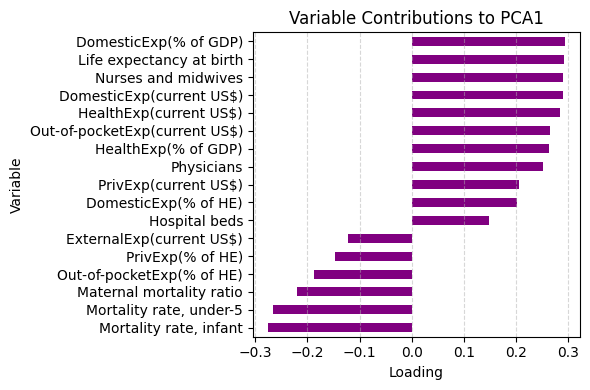

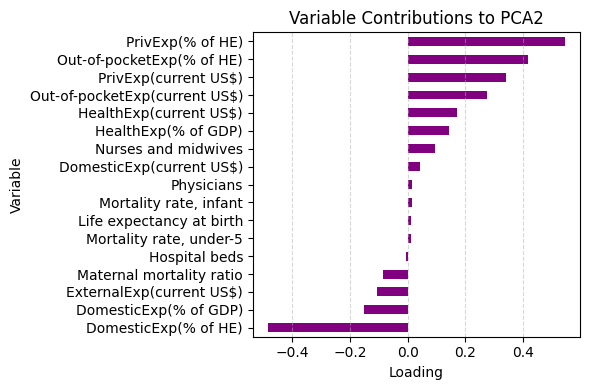

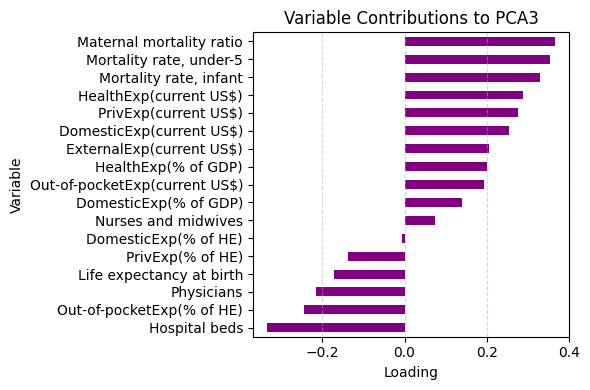

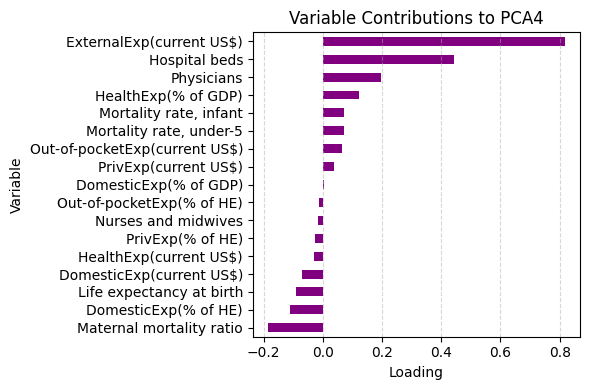

In [22]:
for pc in top4_loadings.columns:
    plt.figure(figsize=(6,4))
    top4_loadings[pc].sort_values().plot(kind='barh', color='purple')
    plt.title(f"Variable Contributions to {pc}")
    plt.xlabel("Loading")
    plt.ylabel("Variable")
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
